**Example**

FILE NAME: toltec_simu_a1400_filtered.fits

The following libraries are required

- sys
- ToltecSignalFits
- InputModelFits
- BdsfCat
- SimuInputSources
- CatalogMatch
- astropy.io.fits
- matplotlib
- numpy

To load the file with open function and to get information about the contents of a FITS file, use the info() function. The objective is to repeat the same flux comparison procedure but it will not be a one-to-one relationship, in this case the values will have to be adjusted.

In [1]:
import sys
sys.path.append('toltec_pybdsf_scripts-main')
from ToltecSignalFits import ToltecSignalFits
from InputModelFits import InputModelFits
from BdsfCat import BdsfCat
from SimuInputSources import SimuInputSources
from CatalogMatch import CatalogMatch

In [4]:
import astropy.io.fits as ft 
ff=ft.open("toltec_simu_a1400_filtered.fits")  
ff.info()

Filename: toltec_simu_a1400_filtered.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      21   ()      
  1  signal_I      1 ImageHDU        34   (3714, 3708, 1, 1)   float64   
  2  weight_I      1 ImageHDU        34   (3714, 3708, 1, 1)   float64   
  3  kernel_I      1 ImageHDU        34   (3714, 3708, 1, 1)   float64   
  4  coverage_I    1 ImageHDU        34   (3714, 3708, 1, 1)   float64   
  5  sig2noise_I    1 ImageHDU        34   (3714, 3708, 1, 1)   float64   
  6  coverage_bool_I    1 ImageHDU        34   (3714, 3708, 1, 1)   float64   


**Toltec SignalFits** is used to load the file, in this case a2000, and weight cut is specified to not use all sources.The edges have a lower weight than the center
Finally, an image is drawn that corresponds to the signal I.

['./toltec_simu_a1400_filtered.fits']
Fits file found: ./toltec_simu_a1400_filtered.fits


<WCSAxesSubplot:>

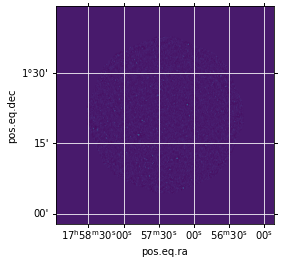

In [5]:
tf1p2 = ToltecSignalFits("./", array='a1400')# to load the file 
tf1p2.setWeightCut(0.5) 
tf1p2.plotImage('signal_I') # show image

Input data is read with **Simu Input Sources**. This class has a method (inphotPS) to perform PSF photometry at the input sources coordinates using a ToltecSignalFits object. Once inphotPS is used, one can plot the comparison between input and observed fluxes.

Now, the comparison between the input data and the TolTEC observations, it doesn't show that there is a one-to-one relationship, so the next step will be to visually get the input flux (flux_a1400_input) and the observed flux (flux_fit) data for be able to manipulate them. This is done with the astrotab ("column name") method.

/Users/mariajosemejiamorales/Desktop/praticas/toltec_pybdsf_scripts-main/ToltecSignalFits.py:574: RuntimeWarning: divide by zero encountered in power
  noise=(tfipj.getMap('weight_I'))**(-0.5)*flux_fact


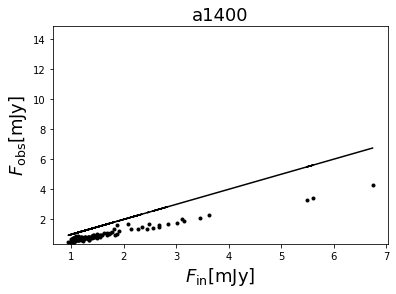

In [34]:
fluxLimit = 2  
sq = SimuInputSources("squareCat_0.01mJy.csv", fluxLimit=fluxLimit ) 
inputtab_phot=sq.inphotPS(tf1p2) 
inputtab_phot.plotInPhot()

astrotab returns the data table of inputtab_phot. We will use the columns flux_a1400_input and flux_fit.

In [35]:
inputtab_phot.astrotab 

x_0,y_0,flux_0,id,group_id,x_fit,y_fit,flux_fit,flux_unc,x_0_unc,y_0_unc,flux_a1400_input,flux_fit_group,flux_unc_group,flux_a1400_input_group
float64,float64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1411.0744025024685,1516.1638886908086,4.176139377829303,1,1,1410.9405128565159,1515.6852092906115,4.27140427200939,0.010786635244656971,0.017684500641735403,0.017674850724926295,6.741,4.871525403018972,0.02157326470376328,8.077
2165.807161263126,612.0708818104447,3.367838442456117,2,2,2165.731812178572,611.7973275999035,3.32024172385499,0.016414040637756217,0.03460446506509479,0.03459316552772073,5.486,3.32024172385499,0.016414040637756217,5.486
2234.3896337860597,2028.9943078251365,3.422859300879661,3,3,2234.47410158274,2028.712114649318,3.4188815706934697,0.00967079517077815,0.01979868015722575,0.019796040318501146,5.605,3.4188815706934697,0.00967079517077815,5.605
1467.084794775431,1761.6824016426967,2.252357729645632,4,4,1467.274386076127,1761.6208374445587,2.2948854492780093,0.00599928698246851,0.018295626568151667,0.018296707755811367,3.629,2.2948854492780093,0.00599928698246851,3.629
2809.2728617939883,2519.8321977238843,2.061899057530391,5,5,2809.389363528933,2519.6344157542094,2.0654527955191693,0.006869171297894621,0.023278451848219497,0.02327445449297881,3.453,2.0654527955191693,0.006869171297894621,3.453
1940.6753084582433,928.0087666685781,1.8634546125050648,6,6,1940.5706138017883,927.2862601195644,1.922022340527186,0.00588103478106179,0.021417283344423704,0.021413823356668856,3.14,1.922022340527186,0.00588103478106179,3.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1243.3870089705338,2116.02883808571,0.6792773062166554,113,109,1243.9890675966906,2116.4598044749573,0.6617763229108173,0.007281366065949324,0.07701204529781351,0.07701765163404711,1.144,0.6617763229108173,0.007281366065949324,1.144
2246.259608881419,2944.073320682821,0.6004224701403282,114,110,2245.5242858854276,2944.6328900561084,0.671503588838931,0.006700062922454578,0.0698217919594101,0.06984872520883702,1.102,0.671503588838931,0.006700062922454578,1.102


In [36]:
inputtab_phot.astrotab.colnames # returns the name of the columns


['x_0',
 'y_0',
 'flux_0',
 'id',
 'group_id',
 'x_fit',
 'y_fit',
 'flux_fit',
 'flux_unc',
 'x_0_unc',
 'y_0_unc',
 'flux_a1400_input',
 'flux_fit_group',
 'flux_unc_group',
 'flux_a1400_input_group']

In [37]:
inputtab_phot.astrotab["flux_fit"] # returns a specific column

4.27140427200939
3.32024172385499
3.4188815706934697
2.2948854492780093
2.0654527955191693
1.922022340527186
2.016775617910734
1.7674194458193735
1.4215076442160872
...
0.6104208433432314


Then, to fit the data we have to find a constant such that the flux input is equal to the flux of the observations.

The following cell shows a small operation to obtain this constant, its mean is indicated with the numpy library method called **mean**.

In [38]:
a=inputtab_phot.astrotab["flux_a1400_input"]/inputtab_phot.astrotab["flux_fit"]
print(a)

 flux_a1400_input 
------------------
1.5781695130507611
1.6522893380276062
1.6394250236819723
1.5813425463749027
1.6717883882367104
1.6336958909326407
1.5405779266702346
               ...
1.7286807647758173
1.6410932395840543
 1.420019699846469
2.0688539561895687
1.7976617006214406
2.0618602535464596
1.8764753124102325
Length = 119 rows


In [39]:
from numpy import mean 
mean(a) 

1.6507109287706543

Now that we got the value of the constant, just multiply it by the flux of observations so that it is as close as possible to the input flux, renamed in this code as fluj_inp.
Since the data for the x-axis and the y-axis are known, it is enough to graph to see the result of the adjustment.

In [40]:
fluj_inp=(mean(a))*inputtab_phot.astrotab["flux_fit"]
print(fluj_inp)

     flux_fit     
------------------
  7.05085371300356
 5.480759299727748
 5.643585172916291
 3.788192491399963
 3.409465502423392
 3.172703282849578
 3.329113553363438
               ...
1.0924014086305438
1.1084583128051393
 1.192680223451692
 0.811450711413063
0.8631592209524255
0.7845811603442842
0.8876041779575867
Length = 119 rows


**Obtaining the graph before the adjustment**

The values of flux_a1400_input will be put on the x-axis and flux_fit on the y-axis. To make the graph, just use the plot command and specify which axis certain data goes on, as well as the color, size, etc.

The one-to-one relationship will also be plotted in this case in a range from 0 to 10. To name the axes, use xlabel(name) depending on which one you want to name, this command has many display options such as font size and color, these specifications will be placed after the title. Finally, to print everything, show() is used.

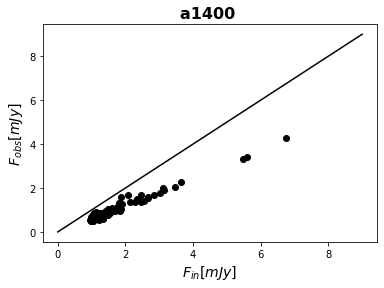

In [93]:
import matplotlib.pyplot as plt
import numpy as np
x=inputtab_phot.astrotab["flux_a1400_input"]
y=inputtab_phot.astrotab["flux_fit"]
x2 = np.arange(0,10)
y2=x2
plt.plot(x,y, "o",color='black')
plt.plot(x2,y2,'-',linewidth=1.5,color='black')
plt.xlabel('$F_{in}[mJy]$',size=14)
plt.ylabel('$F_{\\rm{obs}}[mJy]$',size=14)
plt.title("a1400 ",fontdict={'weight': 'bold',"size":16})
plt.show()


**Obtaining the graph after adjustment**

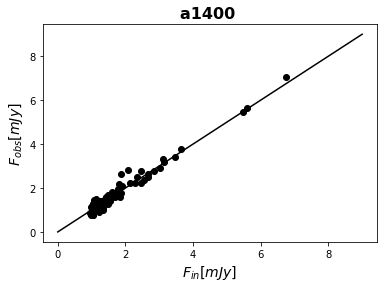

In [92]:
x=inputtab_phot.astrotab["flux_a1400_input"] 
y=fluj_inp # se cambia el eje y
plt.plot(x,y, "o",color='black')
plt.plot(x2,y2,'-',linewidth=1.5,color='black')
plt.xlabel('$F_{in}[mJy]$',size=14)
plt.ylabel('$F_{obs}[mJy]$',size=14)
plt.title("a1400 ",fontdict={'weight': 'bold',"size":16})
plt.show()

As we can see, now the graph has the relationship we were looking for.

**Example**

FILE NAME: toltec_simu_a2000_filtered.fits

We repeat the same procedure.

In [1]:
import sys
sys.path.append('toltec_pybdsf_scripts-main')
from ToltecSignalFits import ToltecSignalFits
from InputModelFits import InputModelFits
from BdsfCat import BdsfCat
from SimuInputSources import SimuInputSources
from CatalogMatch import CatalogMatch

['./toltec_simu_a2000_filtered.fits']
Fits file found: ./toltec_simu_a2000_filtered.fits


<WCSAxesSubplot:>

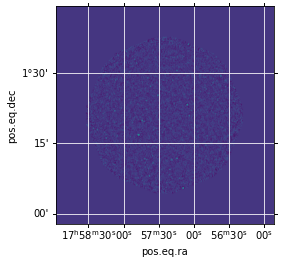

In [6]:
tf1p3 = ToltecSignalFits("./", array='a2000')
tf1p3.setWeightCut(0.5)
tf1p3.plotImage('signal_I')

/Users/mariajosemejiamorales/Desktop/praticas/toltec_pybdsf_scripts-main/ToltecSignalFits.py:574: RuntimeWarning: divide by zero encountered in power
  noise=(tfipj.getMap('weight_I'))**(-0.5)*flux_fact


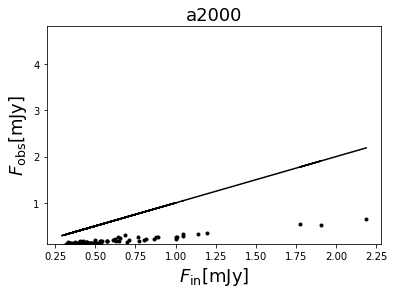

In [25]:
fluxLimit = 2  
sq1 = SimuInputSources("squareCat_0.01mJy.csv", fluxLimit=fluxLimit ) 
inputtab_phot1=sq1.inphotPS(tf1p3) 
inputtab_phot1.plotInPhot()

In [26]:
inputtab_phot1.astrotab

x_0,y_0,flux_0,id,group_id,x_fit,y_fit,flux_fit,flux_unc,x_0_unc,y_0_unc,flux_a2000_input,flux_fit_group,flux_unc_group,flux_a2000_input_group
float64,float64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1411.0744025024685,1516.1638886908086,0.6528764550932247,1,1,1410.638810631773,1515.5705331932106,0.6590318043573896,0.0016977196450407939,0.026752718714512316,0.02534118847212352,2.187,0.8009981794580128,0.0033948187124809423,2.651
2165.807161263126,612.0708818104447,0.54232097020652,2,2,2165.249157791426,611.3872438832651,0.5390701735193136,0.0023681070916826484,0.04359243481725303,0.0435851690466221,1.775,0.5390701735193136,0.0023681070916826484,1.775
2234.3896337860597,2028.9943078251365,0.5335909822503276,3,3,2234.7212359351806,2028.6996198180586,0.5196795184679458,0.002359094279378416,0.04504557568705676,0.04504095783660523,1.904,0.5196795184679458,0.002359094279378416,1.904
1467.084794775431,1761.6824016426967,0.3498199809294901,4,4,1466.7597664031332,1761.436649434035,0.351820479032201,0.0015605623771292876,0.04401066881638245,0.04401295820180223,1.194,0.351820479032201,0.0015605623771292876,1.194
2809.2728617939883,2519.8321977238843,0.32273851059080866,5,5,2809.016777174158,2520.158762958536,0.3248427825987258,0.0013489275371406193,0.041203506935672235,0.04120135437888627,1.142,0.3248427825987258,0.0013489275371406193,1.142
1940.6753084582433,928.0087666685781,0.31418282027294675,6,6,1940.7322926114853,927.140034393252,0.28908663663714385,0.0018094437921152623,0.06210788188462432,0.06210457725592176,1.044,0.28908663663714385,0.0018094437921152623,1.044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1243.3870089705338,2116.02883808571,0.10695501666492406,115,109,1243.927194171935,2119.07790766912,0.09149637240063165,0.0017921595092871634,0.349187777478059,0.3496476729742135,0.427,0.09149637240063165,0.0017921595092871634,0.427
2246.259608881419,2944.073320682821,0.11607037456564395,116,110,2249.77734528743,2942.0249482731147,0.13297381149399326,0.001142867276257971,0.17864939639880512,0.17806640657704625,0.397,0.13297381149399326,0.001142867276257971,0.397


In [28]:
b=inputtab_phot1.astrotab["flux_a2000_input"]/inputtab_phot1.astrotab["flux_fit"]
print(b)

 flux_a2000_input 
------------------
3.3185044872492995
3.2927067517238657
3.6637964982979025
 3.393776289784191
 3.515546785014147
3.6113741269556137
 3.104598825151536
               ...
 4.666851688177445
2.9855502789579993
 4.208872277632607
 6.676238787356808
 4.583227871664143
 2.960082755170199
 4.437653728615055
Length = 121 rows


In [29]:
from numpy import mean 
mean(b) 

3.6816031570770504

In [30]:
fluj_inp2=(mean(b))*inputtab_phot1.astrotab["flux_fit"]
print(fluj_inp2)

      flux_fit     
-------------------
 2.4262935715363505
 1.9846424527147786
 1.9132537558598706
 1.2952633863293113
  1.195942213969163
 1.0643022741120949
 1.2415898873090394
                ...
0.33685333349126295
0.48955680420485415
0.30177990811021094
0.18749255580502927
0.23455698733917899
 0.3967562748224759
 0.2812439966194991
Length = 121 rows


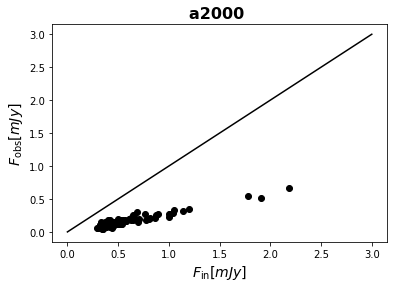

In [31]:
import matplotlib.pyplot as plt
import numpy as np
x=inputtab_phot1.astrotab["flux_a2000_input"]
y=inputtab_phot1.astrotab["flux_fit"]
x2 = np.arange(0,3.5)
y2=x2
plt.plot(x,y, "o",color='black')
plt.plot(x2,y2,'-',linewidth=1.5,color='black')
plt.xlabel('$F_{\\rm{in}}[mJy]$',size=14)
plt.ylabel('$F_{\\rm{obs}}[mJy]$',size=14)
plt.title("a2000 ",fontdict={'weight': 'bold',"size":16})
plt.show()


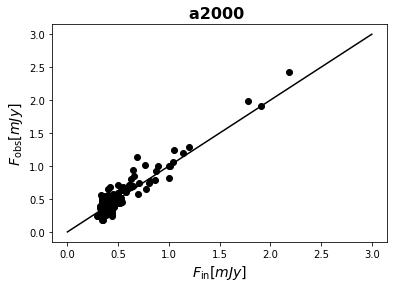

In [32]:
x=inputtab_phot1.astrotab["flux_a2000_input"] 
y=fluj_inp2 
plt.plot(x,y, "o",color='black')
plt.plot(x2,y2,'-',linewidth=1.5,color='black')
plt.xlabel('$F_{\\rm{in}}[mJy]$',size=14)
plt.ylabel('$F_{\\rm{obs}}[mJy]$',size=14)
plt.title("a2000 ",fontdict={'weight': 'bold',"size":16})
plt.show()